[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mbanuelos/grad_math_modeling/blob/main/Lectures/Module0_TimeSeries/02_StationarityAndTransformations.ipynb#copy=true)

# Stationarity: Rolling Statistics, ADF, and Transformations

## Learning objectives

By the end of this lesson, you should be able to:

- Use rolling statistics to diagnose changes in mean and variance.
- Interpret an Augmented Dickey–Fuller test.
- Apply log and differencing transformations for stationarity.

## Setup for this lesson

This cell recreates the data and completed prerequisites from earlier lessons, so this notebook can be run in a fresh kernel.

In [ ]:
# Shared setup from the preceding lesson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']


***
## Part 3 — Rolling Statistics

### What is stationarity?

A time series is **stationary** if its statistical properties — especially its mean and variance —
do not change over time. Many forecasting models assume stationarity, so diagnosing it is a
critical first step.

One visual tool: compute a **rolling mean** and **rolling standard deviation** using a sliding
window. If the series is stationary, both should be roughly flat over time.

### 3.1 Compute and plot rolling statistics

We use a window of 12 months so seasonal effects are averaged out, giving a cleaner view
of the underlying trend and variance.

> 💡 **Syntax reminder:** `series.rolling(window=n).mean()` computes the mean of the last
> `n` observations at each time step. `.std()` does the same for standard deviation.

In [ ]:
# FILL IN: compute 12-month rolling mean and standard deviation
rolling_mean = df['Passengers'].rolling(window=???).mean()
rolling_std  = df['Passengers'].rolling(window=???).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top panel: original + rolling mean
axes[0].plot(df['Passengers'], label='Original', color='steelblue', alpha=0.7)
axes[0].plot(rolling_mean, label='12-Month Rolling Mean', color='crimson', linewidth=2)
axes[0].set_title('Rolling Mean')
axes[0].legend()

# Bottom panel: rolling std
axes[1].plot(rolling_std, label='12-Month Rolling Std', color='darkorange', linewidth=2)
axes[1].set_title('Rolling Standard Deviation')
axes[1].legend()

plt.tight_layout()
plt.show()

### ✏️ Written Response 3.1

1. Is the rolling mean **flat** or does it have a clear direction? What does this imply about stationarity?
2. Is the rolling standard deviation **flat** or does it change over time?
3. Based on these plots alone, would you call this series **stationary**? Justify your answer.

4. What happens if the window length varies for the mean and the standard deviation? In groups of 2 or 3, using the **dividir y confluir** strategy

> **YOUR ANSWER:**

***
## Part 4 — Formal Stationarity Test: Augmented Dickey-Fuller

Visual inspection is useful, but we can also use a **statistical test**.

The **Augmented Dickey-Fuller (ADF) test** tests the following hypotheses:

- **H₀ (null):** The series has a unit root → it is **non-stationary**
- **H₁ (alternative):** The series is **stationary**

| p-value | Conclusion |
|---|---|
| p < 0.05 | Reject H₀ → series is **stationary** |
| p ≥ 0.05 | Fail to reject H₀ → series is likely **non-stationary** |

### 4.1 Run the ADF test on the original series

In [ ]:
# Running ADF test and interpreting
adfuller(df['Passengers'].dropna())

In [ ]:
# Converting result to a function in python
def run_adf(series, label='Series'):
    """Run the ADF test and print a readable summary."""
    ...
    ...


run_adf(df['Passengers'], label='Original Series')

### 4.2 Apply a log transform, then first-difference

Two common transformations to achieve stationarity:

1. **Log transform** → stabilizes *growing variance* (compresses large values)
2. **First difference** → removes a *linear trend* by computing change from one step to the next

> 💡 **Syntax reminder:** `np.log(series)` takes the natural logarithm.
> `series.diff()` computes `x[t] - x[t-1]` for each time step.

In [ ]:
# Step 1: log transform
df['Log_Passengers'] = ???

# FILL IN: first-difference the log series
df['Log_Diff'] = ???

# Run ADF on both
run_adf(df['Log_Passengers'], label='Log-Transformed Series')
run_adf(df['Log_Diff'],       label='Log-Differenced Series')

In [ ]:
# Visualize the two transformed series
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df['Log_Passengers'], color='steelblue')
axes[0].set_title('Log-Transformed Passengers')

# FILL IN: plot the log-differenced series
...
...

plt.tight_layout()
plt.show()

### ✏️ Written Response 4

1. What did the ADF test say about the **original** series? What was the p-value?
2. After log-differencing, what did the ADF test conclude? What changed visually?
3. In your own words, why might a forecasting model perform better on a stationary series
   than on a non-stationary one?

> **YOUR ANSWER:**

In [ ]:
# The effect of delta
# create a simulation to quantify the difference of delta=0 with delta<0
np.random.seed(22)
n_steps = 500

# initialize arrays
y_stat = np.zeros(n_steps)
y_non_stat = np.zeros(n_steps)

In [ ]:
# generate the data
for t in range(1, n_steps):
  # define the noise
  epsilon = np.random.normal()

  y_stat[t] = 0.5 * y_stat[t-1] + epsilon
  y_non_stat[t] = 1 * y_non_stat[t-1] + epsilon

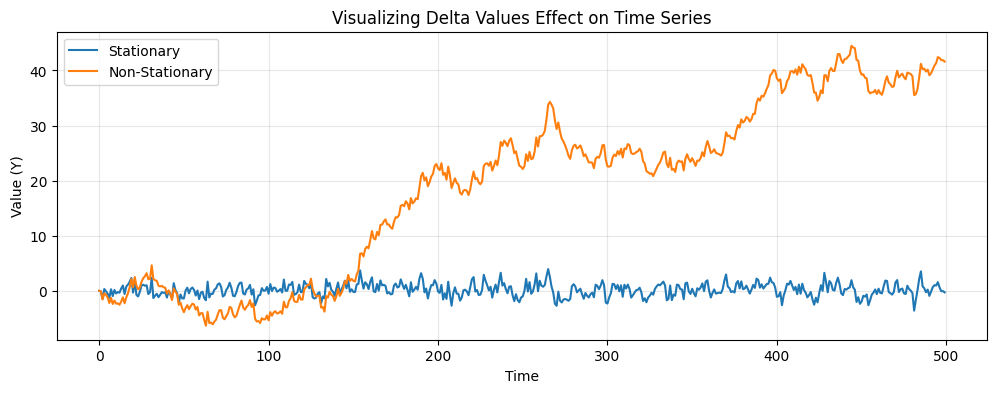

In [6]:
plt.plot(y_stat, label = "Stationary")
plt.plot(y_non_stat, label = "Non-Stationary")
plt.title("Visualizing Delta Values Effect on Time Series")
plt.xlabel("Time")
plt.ylabel("Value (Y)")
plt.legend()